<a href="https://colab.research.google.com/github/ved-ingole/Task-3---Diabetes_Prediction_Model/blob/main/TASK_3_Diabetes_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


════════════════════════════════════════════════════════════
LOADING PIMA DIABETES DATASET
════════════════════════════════════════════════════════════
Dataset Loaded Successfully

Shape : (768, 9)
Columns : ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'target']

Missing values handled successfully

════════════════════════════════════════════════════════════
STEP 1 — FEATURE ENGINEERING
════════════════════════════════════════════════════════════
New Features Created Successfully

════════════════════════════════════════════════════════════
STEP 2 — ENCODING
════════════════════════════════════════════════════════════
Encoding Completed

════════════════════════════════════════════════════════════
STEP 3 — FEATURE SCALING
════════════════════════════════════════════════════════════
Scaling Completed

════════════════════════════════════════════════════════════
STEP 4 — PREPARE FINAL DATA
════════════════════════════════════════════════════════════
Training Samples 

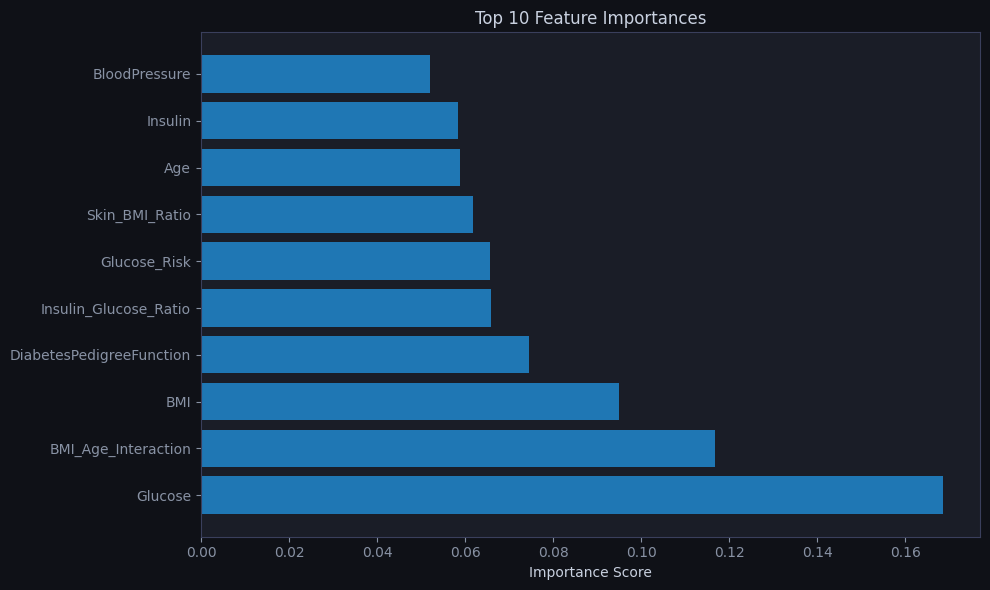


Feature Importance Graph Saved

════════════════════════════════════════════════════════════
TASK 3 COMPLETED SUCCESSFULLY
════════════════════════════════════════════════════════════


In [ ]:
# ─────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    OrdinalEncoder
)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

os.makedirs("outputs", exist_ok=True)

# ─────────────────────────────────────────────────────────────
# STYLE
# ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#3a3f5c",
    "axes.labelcolor": "#c9d1e0",
    "xtick.color": "#8892a4",
    "ytick.color": "#8892a4",
    "text.color": "#c9d1e0",
    "grid.color": "#2a2f45",
    "font.family": "DejaVu Sans",
})

ACCENT  = "#7c6af7"
ACCENT2 = "#06b6d4"
ACCENT3 = "#f59e0b"
ACCENT4 = "#10b981"
RED      = "#f87171"
BG       = "#0f1117"
CARD     = "#1a1d27"

# ─────────────────────────────────────────────────────────────
# LOAD DATASET
# ─────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("LOADING PIMA DIABETES DATASET")
print("═"*60)

# CORRECTED DATASET LOADING
pima = fetch_openml(name="diabetes", version=1, as_frame=True)

df_raw = pima.frame.copy()

# Rename target column properly
df_raw.rename(columns={"class": "target"}, inplace=True)

# Convert target to numeric
df_raw["target"] = df_raw["target"].map({
    "tested_negative": 0,
    "tested_positive": 1
})

print("Dataset Loaded Successfully")

print(f"\nShape : {df_raw.shape}")
print(f"Columns : {list(df_raw.columns)}")

# ─────────────────────────────────────────────────────────────
# HANDLE ZERO VALUES
# ─────────────────────────────────────────────────────────────
zero_cols = [
    "plas",
    "pres",
    "skin",
    "insu",
    "mass"
]

# Rename columns to readable names
df_raw.columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "target"
]

zero_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in zero_cols:
    df_raw[col] = df_raw[col].replace(0, np.nan)
    df_raw[col].fillna(df_raw[col].median(), inplace=True)

print("\nMissing values handled successfully")

# ─────────────────────────────────────────────────────────────
# STEP 1 — FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("STEP 1 — FEATURE ENGINEERING")
print("═"*60)

df = df_raw.copy()

# BMI Category
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Age Group
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Young", "Middle", "Senior", "Elderly"]
)

# Glucose Risk
df["Glucose_Risk"] = pd.cut(
    df["Glucose"],
    bins=[0, 99, 125, 300],
    labels=["Normal", "Prediabetes", "Diabetes"]
)

# Ratio Feature
df["Insulin_Glucose_Ratio"] = (
    df["Insulin"] / (df["Glucose"] + 1e-5)
)

# Interaction Feature
df["BMI_Age_Interaction"] = (
    df["BMI"] * df["Age"]
)

# Binary Flags
df["High_Pedigree"] = (
    df["DiabetesPedigreeFunction"] > 0.5
).astype(int)

df["High_Pregnancies"] = (
    df["Pregnancies"] >= 4
).astype(int)

# Additional Feature
df["Skin_BMI_Ratio"] = (
    df["SkinThickness"] / (df["BMI"] + 1e-5)
)

print("New Features Created Successfully")

# ─────────────────────────────────────────────────────────────
# STEP 2 — ENCODING
# ─────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("STEP 2 — ENCODING")
print("═"*60)

df_enc = df.copy()

ordinal_map = {
    "BMI_Category": [
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ],

    "Age_Group": [
        "Young",
        "Middle",
        "Senior",
        "Elderly"
    ],

    "Glucose_Risk": [
        "Normal",
        "Prediabetes",
        "Diabetes"
    ]
}

oe = OrdinalEncoder(
    categories=[
        ordinal_map[c]
        for c in ordinal_map.keys()
    ]
) #converts categories into ordered numbers

df_enc[list(ordinal_map.keys())] = oe.fit_transform(
    df_enc[list(ordinal_map.keys())].astype(str)
)

# One Hot Encoding Example
df_enc["Region"] = pd.cut(
    df_enc["Age"],
    bins=[0, 30, 60, 100],
    labels=["Urban", "Suburban", "Rural"]
)

df_enc = pd.get_dummies(
    df_enc,
    columns=["Region"]
)

print("Encoding Completed")

# ─────────────────────────────────────────────────────────────
# STEP 3 — SCALING
# ─────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("STEP 3 — FEATURE SCALING")
print("═"*60)

X_raw = df_enc.drop("target", axis=1)
y = df_enc["target"]

numeric_cols = X_raw.select_dtypes(
    include=[np.number]
).columns.tolist()

# Standard Scaler
scaler = StandardScaler()

X_scaled = X_raw.copy()

X_scaled[numeric_cols] = scaler.fit_transform(
    X_raw[numeric_cols]
)

print("Scaling Completed")

# ─────────────────────────────────────────────────────────────
# STEP 4 — TRAIN TEST SPLIT
# ─────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("STEP 4 — PREPARE FINAL DATA")
print("═"*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

# ─────────────────────────────────────────────────────────────
# MODEL TRAINING
# ─────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("RANDOM FOREST MODEL")
print("═"*60)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy : {accuracy*100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ─────────────────────────────────────────────────────────────
# FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    "Feature": X_scaled.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Important Features:\n")
print(importance_df.head(10))

# ─────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(10,6))

top_features = importance_df.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")

plt.tight_layout()

plt.savefig("outputs/feature_importance.png")

plt.show()

print("\nFeature Importance Graph Saved")

print("\n" + "═"*60)
print("TASK 3 COMPLETED SUCCESSFULLY")
print("═"*60)